In [37]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn (for visualization later)
from sklearn.model_selection import train_test_split

# Device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [38]:
train_df = pd.read_csv("emnist-balanced-train.csv", header=None)
test_df = pd.read_csv("emnist-balanced-test.csv", header=None)

print(train_df.shape)

(112800, 785)


In [39]:
y_train = train_df.iloc[:,0].values
X_train = train_df.iloc[:,1:].values

y_test = test_df.iloc[:,0].values
X_test = test_df.iloc[:,1:].values


In [40]:
X_train = X_train/255.0
X_test = X_test/255.0

In [41]:
def fix_rotation(X):
    X = X.reshape(-1, 28, 28)
    
    X = np.rot90(X, k=1, axes=(1, 2))  # 90° clockwise
    X = np.fliplr(X)                   # mirror (horizontal flip)
    
      
    
    return X

X_train=fix_rotation(X_train)
X_test = fix_rotation(X_test)

In [42]:
X_train_cnn = X_train.reshape(-1, 1, 28, 28)
X_test_cnn = X_test.reshape(-1, 1, 28, 28)

In [43]:
mapping = {}

with open("emnist-balanced-mapping.txt") as f:
    for line in f:
        label, ascii_code = map(int, line.strip().split())
        mapping[label] = chr(ascii_code)

print("Sample mappings:", dict(list(mapping.items())[:5]))

Sample mappings: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4'}


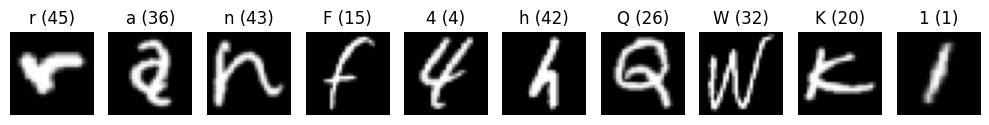

In [44]:
def show_images(X, y, n=5):
    plt.figure(figsize=(10, 2))
    
    for i in range(n):
        plt.subplot(1, n, i+1)
        # For CNN data: squeeze to remove channel dimension
        img = X[i].squeeze()  # (1, 28, 28) -> (28, 28)
        plt.imshow(img, cmap='gray')
        
        label = int(y[i])
        char = mapping[label]
        
        plt.title(f"{char} ({label})")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

show_images(X_train_cnn, y_train, n=10)

In [45]:
X_train_cnn = torch.tensor(X_train_cnn, dtype=torch.float32).to(device)
X_test_cnn = torch.tensor(X_test_cnn, dtype=torch.float32).to(device)

In [46]:
class AE_CNN_1(nn.Module):
    def __init__(self):
        super().__init__()
        
        # ENCODER: Compress spatial dimensions while increasing channels
        self.encoder = nn.Sequential(
            # Layer 1: (1, 28, 28) -> (16, 28, 28)
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> (16, 14, 14)
            
            # Layer 2: (16, 14, 14) -> (32, 14, 14)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> (32, 7, 7)
            
            # Layer 3: (32, 7, 7) -> (64, 7, 7) ← BOTTLENECK
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # DECODER: Reconstruct spatial dimensions
        self.decoder = nn.Sequential(
            # Layer 1: (64, 7, 7) -> (32, 14, 14)
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            
            # Layer 2: (32, 14, 14) -> (16, 28, 28)
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            
            # Layer 3: (16, 28, 28) -> (1, 28, 28)
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()  # Output range [0, 1]
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Create model and check architecture
model_cnn1 = AE_CNN_1().to(device)
print(model_cnn1)
print("\nTotal parameters:", sum(p.numel() for p in model_cnn1.parameters()))

AE_CNN_1(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)

Total parameters: 33729


In [47]:
class AE_CNN_2(nn.Module):
    def __init__(self):
        super().__init__()
        
        # ENCODER: Deeper architecture with BatchNorm
        self.encoder = nn.Sequential(
            # Layer 1: (1, 28, 28) -> (32, 28, 28)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> (32, 14, 14)
            
            # Layer 2: (32, 14, 14) -> (64, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # -> (64, 7, 7)
            
            # Layer 3: (64, 7, 7) -> (128, 7, 7) ← BOTTLENECK
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # DECODER: Mirror encoder with upsampling
        self.decoder = nn.Sequential(
            # Layer 1: (128, 7, 7) -> (64, 14, 14)
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            # Layer 2: (64, 14, 14) -> (32, 28, 28)
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            # Layer 3: (32, 28, 28) -> (1, 28, 28)
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Create model and check architecture
model_cnn2 = AE_CNN_2().to(device)
print(model_cnn2)
print("\nTotal parameters:", sum(p.numel() for p in model_cnn2.parameters()))

AE_CNN_2(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(64, 32, kernel_size=(2, 2),

In [48]:
# Create datasets (input = target for autoencoders)
train_dataset_cnn = TensorDataset(X_train_cnn, X_train_cnn)
test_dataset_cnn = TensorDataset(X_test_cnn, X_test_cnn)

# Create dataloaders
batch_size = 64
train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=batch_size)

print(f"Train batches: {len(train_loader_cnn)}")
print(f"Test batches: {len(test_loader_cnn)}")

Train batches: 1763
Test batches: 294


In [49]:
def train_autoencoder(model, train_loader, test_loader, epochs=10, lr=0.001, model_name="Model"):
    """
    Train an autoencoder model
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        test_loader: Validation data loader
        epochs: Number of training epochs
        lr: Learning rate
        model_name: Name for logging
    
    Returns:
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
    """
    
    # Loss function and optimizer
    criterion = nn.MSELoss()  # Mean Squared Error for reconstruction
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Track losses
    train_losses = []
    val_losses = []
    
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}\n")
    
    for epoch in range(epochs):
        # ========== TRAINING ==========
        model.train()
        train_loss = 0
        
        for X_batch, _ in train_loader:
            # Forward pass
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, X_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for X_batch, _ in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, X_batch)
                val_loss += loss.item()
        
        val_loss /= len(test_loader)
        
        # Store losses
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # Print progress
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    print(f"\n{'='*50}")
    print(f"Training Complete!")
    print(f"Final Train Loss: {train_losses[-1]:.6f}")
    print(f"Final Val Loss: {val_losses[-1]:.6f}")
    print(f"{'='*50}\n")
    
    return train_losses, val_losses

In [50]:
# Train CNN Model 1
train_losses_cnn1, val_losses_cnn1 = train_autoencoder(
    model=model_cnn1,
    train_loader=train_loader_cnn,
    test_loader=test_loader_cnn,
    epochs=10,
    lr=0.001,
    model_name="AE_CNN_1 (Simple)"
)


Training AE_CNN_1 (Simple)

Epoch 1/10 | Train Loss: 0.009186 | Val Loss: 0.002688
Epoch 2/10 | Train Loss: 0.002324 | Val Loss: 0.002068
Epoch 3/10 | Train Loss: 0.001948 | Val Loss: 0.001785
Epoch 4/10 | Train Loss: 0.001698 | Val Loss: 0.001623
Epoch 5/10 | Train Loss: 0.001506 | Val Loss: 0.001434
Epoch 6/10 | Train Loss: 0.001361 | Val Loss: 0.001294
Epoch 7/10 | Train Loss: 0.001245 | Val Loss: 0.001213
Epoch 8/10 | Train Loss: 0.001159 | Val Loss: 0.001118
Epoch 9/10 | Train Loss: 0.001088 | Val Loss: 0.001062
Epoch 10/10 | Train Loss: 0.001033 | Val Loss: 0.000988

Training Complete!
Final Train Loss: 0.001033
Final Val Loss: 0.000988



In [51]:
# Train CNN Model 2
train_losses_cnn2, val_losses_cnn2 = train_autoencoder(
    model=model_cnn2,
    train_loader=train_loader_cnn,
    test_loader=test_loader_cnn,
    epochs=8,
    lr=0.001,
    model_name="AE_CNN_2 (Deeper + BatchNorm)"
)


Training AE_CNN_2 (Deeper + BatchNorm)

Epoch 1/8 | Train Loss: 0.002635 | Val Loss: 0.000789
Epoch 2/8 | Train Loss: 0.000719 | Val Loss: 0.000645
Epoch 3/8 | Train Loss: 0.000540 | Val Loss: 0.000463
Epoch 4/8 | Train Loss: 0.000458 | Val Loss: 0.000568
Epoch 5/8 | Train Loss: 0.000395 | Val Loss: 0.000469
Epoch 6/8 | Train Loss: 0.000363 | Val Loss: 0.000457
Epoch 7/8 | Train Loss: 0.000335 | Val Loss: 0.000383
Epoch 8/8 | Train Loss: 0.000313 | Val Loss: 0.000349

Training Complete!
Final Train Loss: 0.000313
Final Val Loss: 0.000349



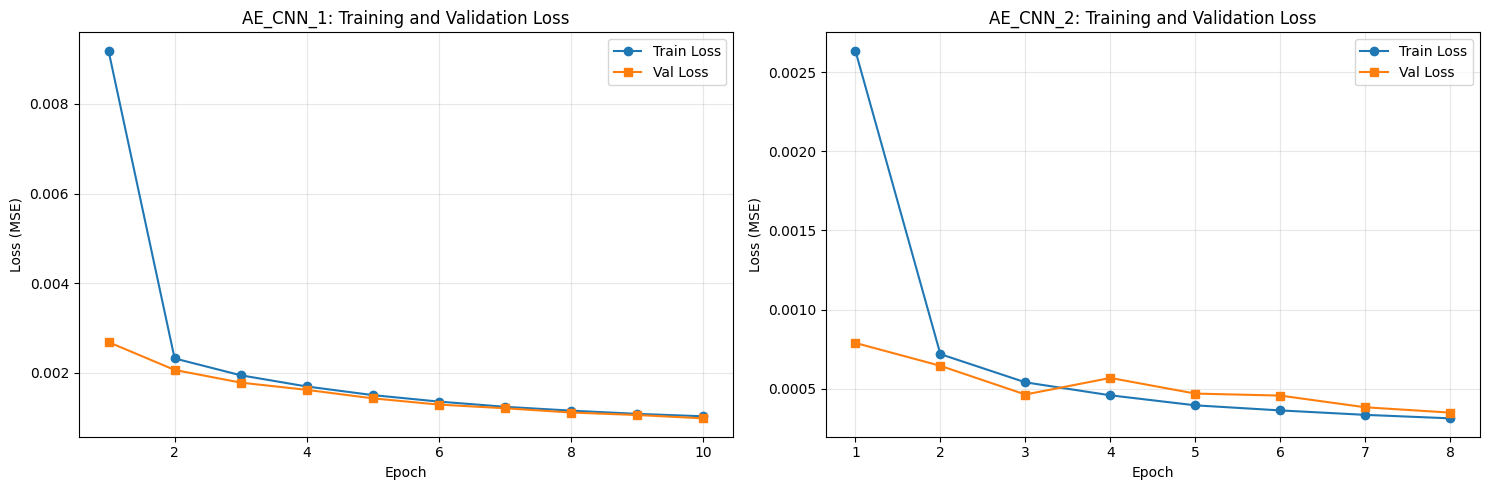

In [52]:
# Plot individual model curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# CNN Model 1
axes[0].plot(range(1, len(train_losses_cnn1)+1), train_losses_cnn1, label='Train Loss', marker='o')
axes[0].plot(range(1, len(val_losses_cnn1)+1), val_losses_cnn1, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('AE_CNN_1: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CNN Model 2
axes[1].plot(range(1, len(train_losses_cnn2)+1), train_losses_cnn2, label='Train Loss', marker='o')
axes[1].plot(range(1, len(val_losses_cnn2)+1), val_losses_cnn2, label='Val Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title('AE_CNN_2: Training and Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

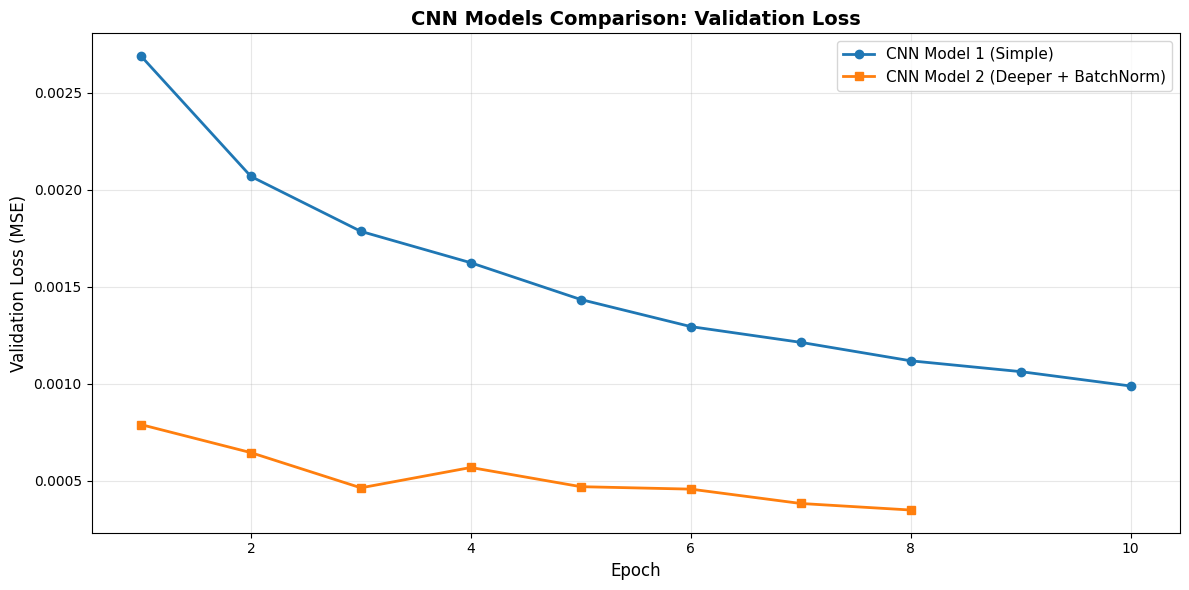


MODEL COMPARISON
CNN Model 1 - Final Val Loss: 0.000988
CNN Model 2 - Final Val Loss: 0.000349

Best Model: CNN Model 2


In [53]:
# Compare both models
plt.figure(figsize=(12, 6))

plt.plot(range(1, len(val_losses_cnn1)+1), val_losses_cnn1, 
         label='CNN Model 1 (Simple)', marker='o', linewidth=2)
plt.plot(range(1, len(val_losses_cnn2)+1), val_losses_cnn2, 
         label='CNN Model 2 (Deeper + BatchNorm)', marker='s', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss (MSE)', fontsize=12)
plt.title('CNN Models Comparison: Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"CNN Model 1 - Final Val Loss: {val_losses_cnn1[-1]:.6f}")
print(f"CNN Model 2 - Final Val Loss: {val_losses_cnn2[-1]:.6f}")
print(f"\nBest Model: {'CNN Model 1' if val_losses_cnn1[-1] < val_losses_cnn2[-1] else 'CNN Model 2'}")
print("="*60)

In [54]:
def show_reconstruction_cnn(model, X, y=None, n=10, model_name="Model"):
    """
    Visualize original and reconstructed images
    
    Args:
        model: Trained autoencoder
        X: Input images tensor (N, 1, 28, 28)
        y: Labels (optional, for titles)
        n: Number of samples to show
        model_name: Model name for title
    """
    model.eval()
    
    with torch.no_grad():
        recon = model(X[:n])
    
    plt.figure(figsize=(2*n, 4))
    
    for i in range(n):
        # Original image
        plt.subplot(2, n, i+1)
        plt.imshow(X[i].cpu().squeeze(), cmap='gray')
        if y is not None:
            label = int(y[i])
            char = mapping.get(label, '?')
            plt.title(f"{char}", fontsize=10)
        else:
            plt.title("Original", fontsize=10)
        plt.axis('off')
        
        # Reconstructed image
        plt.subplot(2, n, i+n+1)
        plt.imshow(recon[i].cpu().squeeze(), cmap='gray')
        plt.title("Recon", fontsize=10)
        plt.axis('off')
    
    plt.suptitle(f"{model_name}: Original vs Reconstructed", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

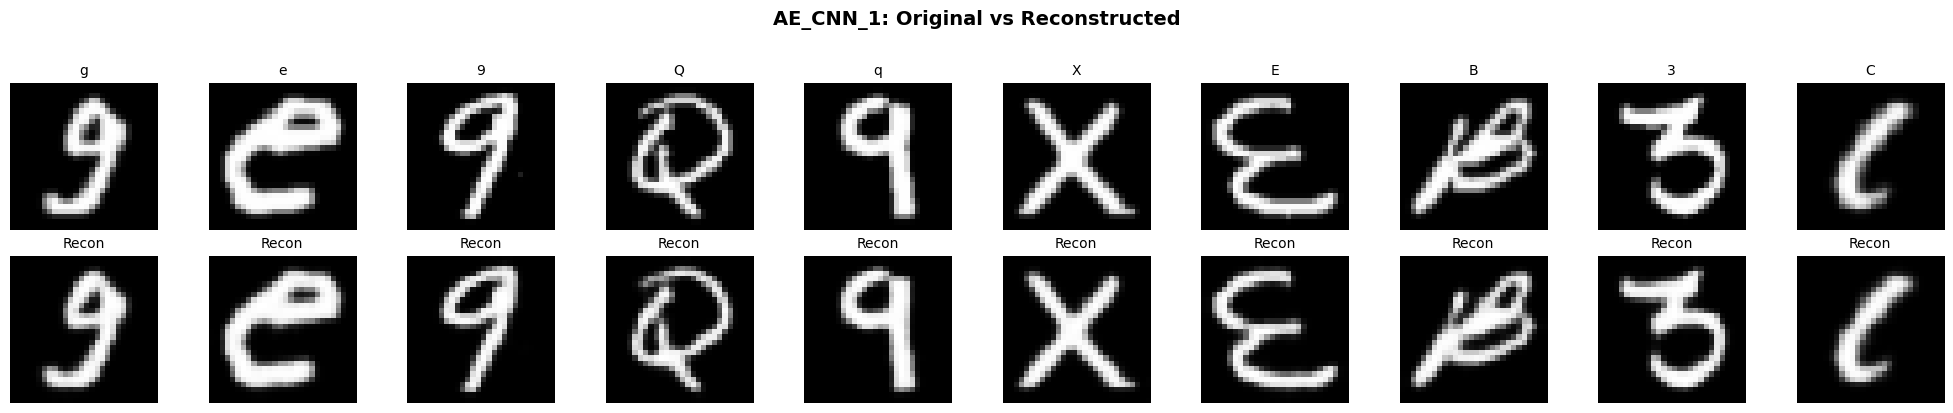

In [55]:
# Show reconstructions for CNN Model 1
show_reconstruction_cnn(model_cnn1, X_test_cnn, y_test, n=10, model_name="AE_CNN_1")

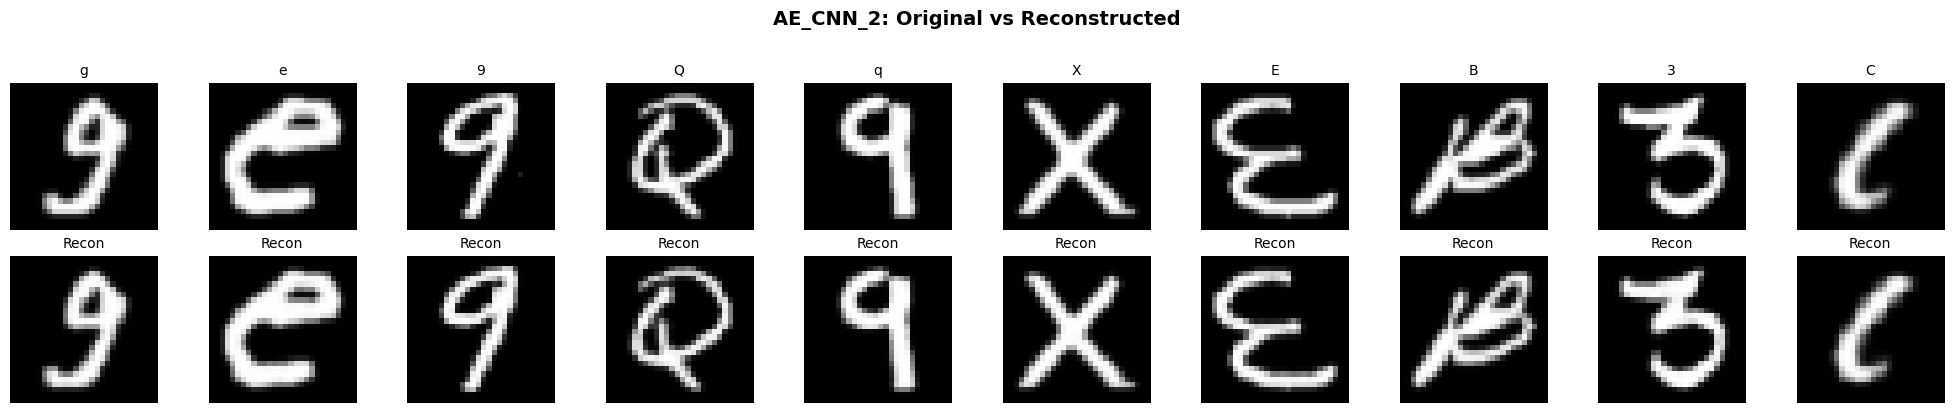

In [56]:
# Show reconstructions for CNN Model 2
show_reconstruction_cnn(model_cnn2, X_test_cnn, y_test, n=10, model_name="AE_CNN_2")

In [57]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
def visualize_latent_space(model, X, y, model_name="Model", n_samples=5000):
    """
    Visualize latent space using PCA and t-SNE
    
    Args:
        model: Trained autoencoder
        X: Input images
        y: Labels for coloring
        model_name: Model name for titles
        n_samples: Number of samples for t-SNE (for speed)
    """
    # Extract latent representations
    model.eval()
    with torch.no_grad():
        latent = model.encoder(X)  # Shape: (N, C, H, W)
    
    # Flatten latent space
    latent_flat = latent.view(latent.size(0), -1).cpu().numpy()
    labels_np = y
    
    print(f"\nLatent space shape: {latent.shape}")
    print(f"Flattened shape: {latent_flat.shape}")
    print(f"Total features in bottleneck: {latent_flat.shape[1]}")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # ========== PCA (Fast) ==========
    print("\nComputing PCA...")
    pca = PCA(n_components=2)
    latent_pca = pca.fit_transform(latent_flat)
    
    scatter1 = axes[0].scatter(latent_pca[:, 0], latent_pca[:, 1],
                               c=labels_np, cmap='tab20', s=1, alpha=0.5)
    axes[0].set_xlabel('PC 1', fontsize=12)
    axes[0].set_ylabel('PC 2', fontsize=12)
    axes[0].set_title(f'{model_name}: PCA Latent Space', fontsize=13, fontweight='bold')
    plt.colorbar(scatter1, ax=axes[0], label='Class Label')
    
    # ========== t-SNE (Slower but better separation) ==========
    print("Computing t-SNE (this may take a minute)...")
    subset_idx = min(n_samples, len(latent_flat))
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    latent_tsne = tsne.fit_transform(latent_flat[:subset_idx])
    
    scatter2 = axes[1].scatter(latent_tsne[:, 0], latent_tsne[:, 1],
                               c=labels_np[:subset_idx], cmap='tab20', s=5, alpha=0.6)
    axes[1].set_xlabel('t-SNE 1', fontsize=12)
    axes[1].set_ylabel('t-SNE 2', fontsize=12)
    axes[1].set_title(f'{model_name}: t-SNE Latent Space', fontsize=13, fontweight='bold')
    plt.colorbar(scatter2, ax=axes[1], label='Class Label')
    
    plt.tight_layout()
    plt.show()
    print("Done!\n")


Latent space shape: torch.Size([18800, 64, 7, 7])
Flattened shape: (18800, 3136)
Total features in bottleneck: 3136

Computing PCA...
Computing t-SNE (this may take a minute)...


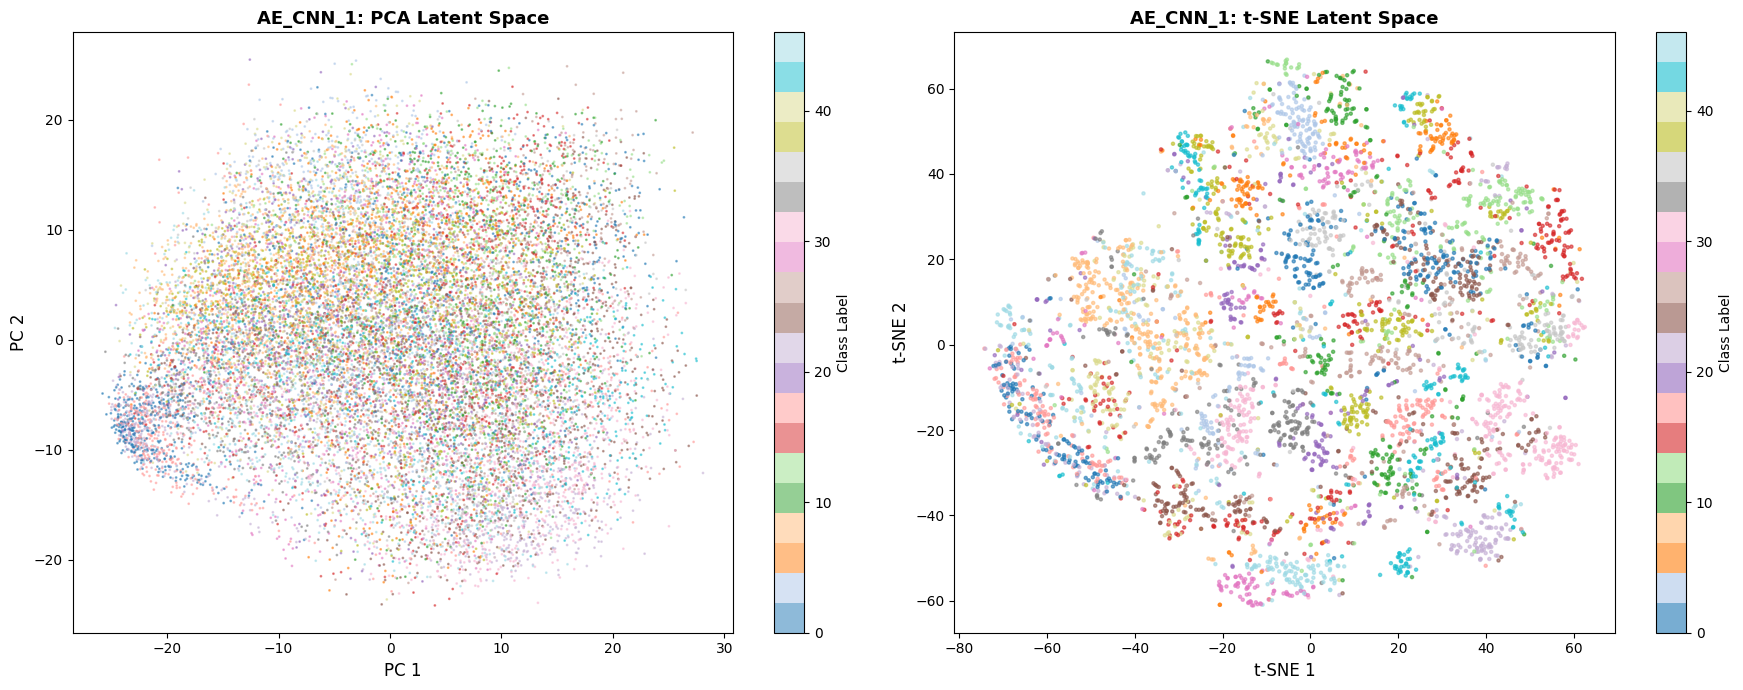

Done!



In [58]:
# Visualize latent space for CNN Model 1
visualize_latent_space(model_cnn1, X_test_cnn, y_test, model_name="AE_CNN_1")


Latent space shape: torch.Size([18800, 128, 7, 7])
Flattened shape: (18800, 6272)
Total features in bottleneck: 6272

Computing PCA...
Computing t-SNE (this may take a minute)...


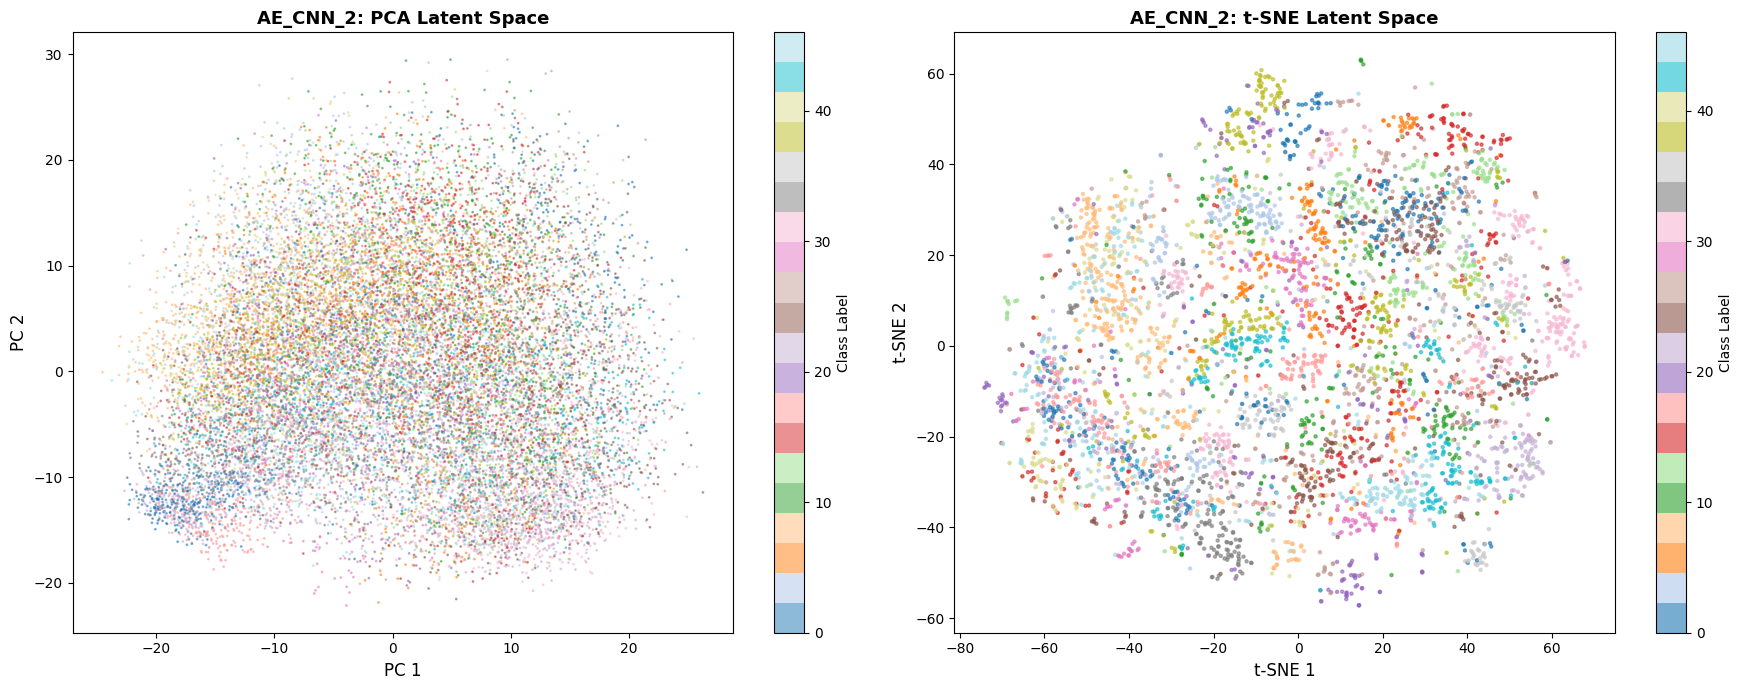

Done!



In [59]:
# Visualize latent space for CNN Model 2
visualize_latent_space(model_cnn2, X_test_cnn, y_test, model_name="AE_CNN_2")

In [60]:
# Find indices of specific characters
def find_character_samples(y, target_labels, n_per_label=5):
    """
    Find sample indices for specific character labels
    """
    indices = []
    for label in target_labels:
        label_indices = np.where(y == label)[0]
        selected = np.random.choice(label_indices, size=min(n_per_label, len(label_indices)), replace=False)
        indices.extend(selected)
    return indices

# Select some interesting characters
# You can change these labels based on your dataset
interesting_labels = [0, 1, 2, 10, 20, 30]  # Modify as needed
sample_indices = find_character_samples(y_test, interesting_labels, n_per_label=2)

print(f"Selected {len(sample_indices)} samples from labels: {interesting_labels}")
print("\nCharacter mapping:")
for label in interesting_labels:
    print(f"Label {label}: '{mapping.get(label, '?')}'")

Selected 12 samples from labels: [0, 1, 2, 10, 20, 30]

Character mapping:
Label 0: '0'
Label 1: '1'
Label 2: '2'
Label 10: 'A'
Label 20: 'K'
Label 30: 'U'


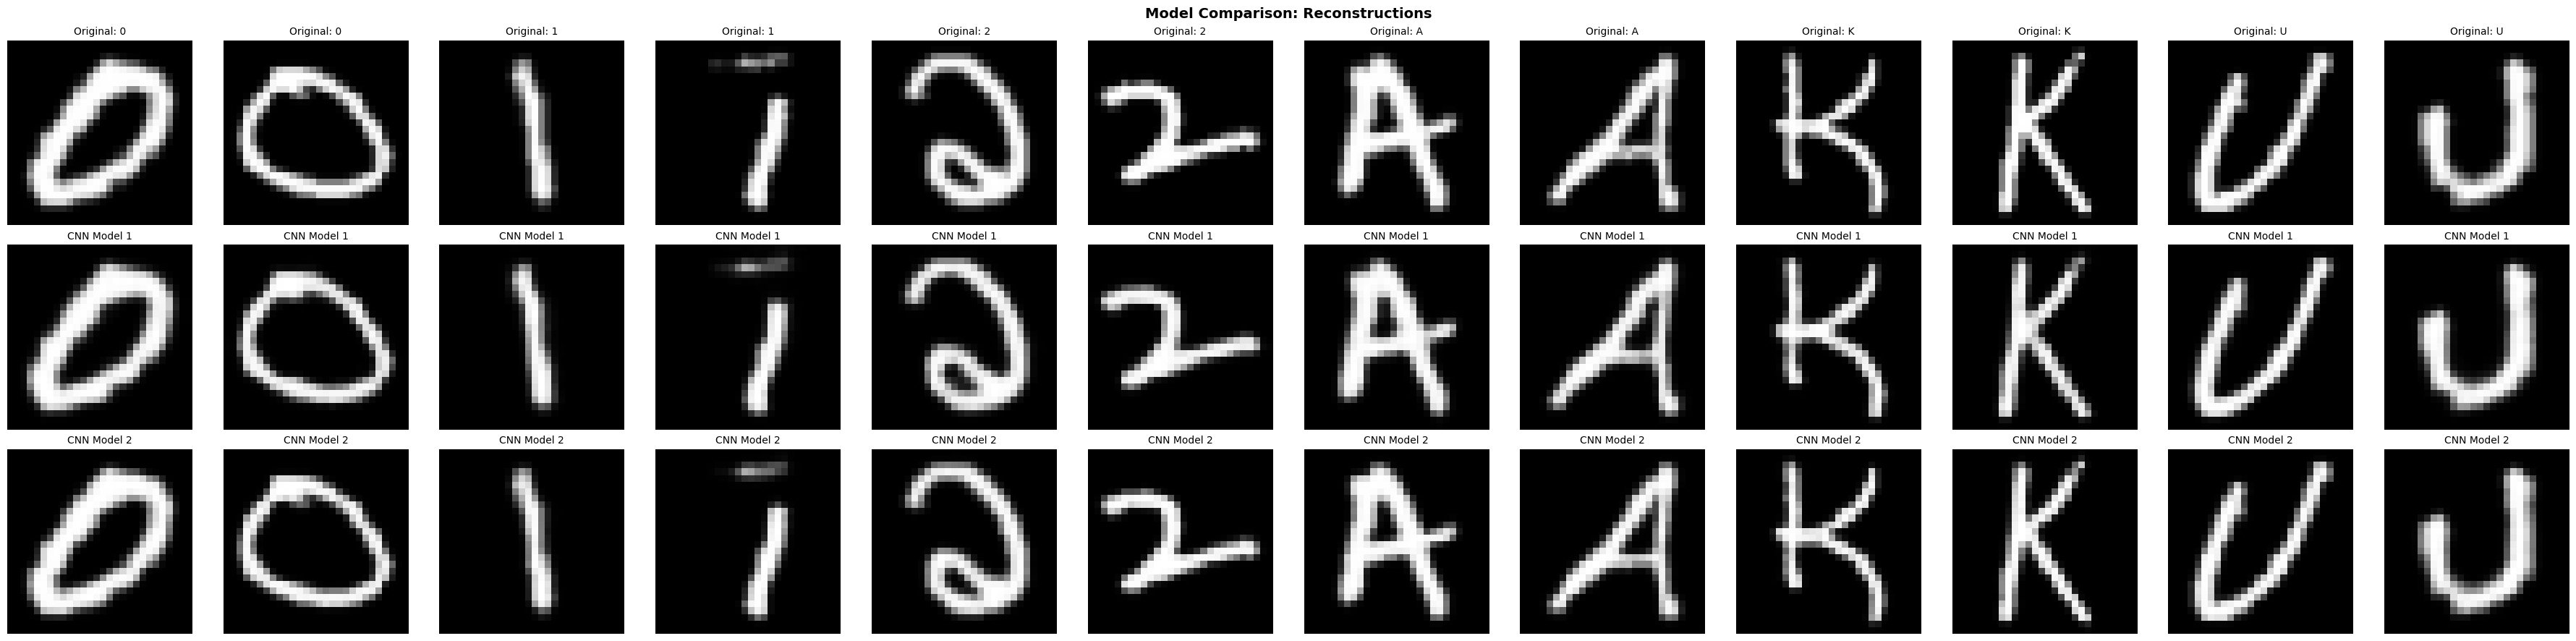

In [61]:
# Compare reconstructions side by side
def compare_models(model1, model2, X, indices, y=None):
    """
    Compare reconstructions from two different models
    """
    n = len(indices)
    X_samples = X[indices]
    
    model1.eval()
    model2.eval()
    
    with torch.no_grad():
        recon1 = model1(X_samples)
        recon2 = model2(X_samples)
    
    plt.figure(figsize=(3*n, 9))
    
    for i in range(n):
        # Original
        plt.subplot(3, n, i+1)
        plt.imshow(X_samples[i].cpu().squeeze(), cmap='gray')
        if y is not None:
            label = int(y[indices[i]])
            char = mapping.get(label, '?')
            plt.title(f"Original: {char}", fontsize=10)
        else:
            plt.title("Original", fontsize=10)
        plt.axis('off')
        
        # CNN Model 1
        plt.subplot(3, n, i+n+1)
        plt.imshow(recon1[i].cpu().squeeze(), cmap='gray')
        plt.title("CNN Model 1", fontsize=10)
        plt.axis('off')
        
        # CNN Model 2
        plt.subplot(3, n, i+2*n+1)
        plt.imshow(recon2[i].cpu().squeeze(), cmap='gray')
        plt.title("CNN Model 2", fontsize=10)
        plt.axis('off')
    
    plt.suptitle("Model Comparison: Reconstructions", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

compare_models(model_cnn1, model_cnn2, X_test_cnn, sample_indices, y_test)